In [12]:
csv_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/historical_stock_data_full.csv'

In [13]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# Khai báo thư viện cho toàn bộ tài liệu

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
from scipy.optimize import minimize

In [15]:
# Kiểm tra số liệu

df_week2 = pd.read_csv(csv_path)
print("5 hàng đầu tiên của DataFrame:")
display(df_week2.head())

5 hàng đầu tiên của DataFrame:


,Date,Open,High,Low,Close,Volume,symbol
0,2021-01-04,10.07,10.32,10.07,10.32,2800,DPP
1,2021-01-05,10.27,10.27,10.27,10.27,100,DPP
2,2021-01-06,10.27,10.27,10.27,10.27,0,DPP
3,2021-01-07,10.27,10.27,10.27,10.27,0,DPP
4,2021-01-08,10.27,10.27,10.27,10.27,0,DPP


In [16]:
# Lọc danh mục cổ phiếu theo mã để phân tích
selected_symbols = ['MHC', 'MBB', 'FRT', 'HAH', 'VGI', 'KDH']

symbol_col = next((c for c in df_week2.columns if c.lower() in ['symbol', 'ticker', 'code', 'stock']), None)

df_portfolio = df_week2[df_week2[symbol_col].isin(selected_symbols)].copy()
print('Số lượng bản ghi trong danh mục:', len(df_portfolio))
print('Các mã xuất hiện trong danh mục:')
print(sorted(df_portfolio[symbol_col].unique()))

display(df_portfolio.head())

Số lượng bản ghi trong danh mục: 7481
Các mã xuất hiện trong danh mục:
['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']


,Date,Open,High,Low,Close,Volume,symbol
415838,2021-01-04,18.31,18.40,18.05,18.23,1284600,KDH
415839,2021-01-05,18.13,18.31,18.05,18.25,886200,KDH
415840,2021-01-06,18.25,19.12,18.25,18.62,1741400,KDH
415841,2021-01-07,18.68,19.05,18.62,18.80,1646400,KDH
415842,2021-01-08,18.99,19.05,18.65,18.94,1314900,KDH


In [17]:
# Tính lợi nhuận kỳ vọng (weighted average) cho từng tài sản
df_portfolio = df_portfolio.sort_values([symbol_col, 'Date']).copy()
df_portfolio['Return'] = df_portfolio.groupby(symbol_col)['Close'].pct_change()

expected_returns = (
    df_portfolio.dropna(subset=['Return'])
    .groupby(symbol_col)['Return']
    .apply(lambda x: np.average(x, weights=np.ones(len(x))))
    .rename('Expected_Return')
)

expected_returns_pct = expected_returns * 100
print('Lợi nhuận kỳ vọng của từng tài sản (weighted average trên các phiên giao dịch):')
display(expected_returns_pct.round(4).rename('Expected_Return_%'))

# Tính phương sai và hiệp phương sai cho lợi nhuận
returns_pivot = (
    df_portfolio[['Date', symbol_col, 'Return']]
    .dropna(subset=['Return'])
    .groupby(['Date', symbol_col])['Return']
    .mean()
    .unstack(symbol_col)
)

variance = returns_pivot.var(ddof=1).rename('Variance')
covariance = returns_pivot.cov(ddof=1)

print('Phương sai của lợi nhuận từng tài sản:')
display(variance.round(8))
print('Ma trận hiệp phương sai giữa các tài sản:')
display(covariance.round(8))

Lợi nhuận kỳ vọng của từng tài sản (weighted average trên các phiên giao dịch):


symbol
FRT    0.2218
HAH    0.2327
KDH    0.0690
MBB    0.1110
MHC    0.0830
VGI    0.1034
Name: Expected_Return_%, dtype: float64

Phương sai của lợi nhuận từng tài sản:


symbol
FRT    0.000742
HAH    0.000861
KDH    0.000498
MBB    0.000392
MHC    0.000988
VGI    0.000917
Name: Variance, dtype: float64

Ma trận hiệp phương sai giữa các tài sản:


symbol,FRT,HAH,KDH,MBB,MHC,VGI
symbol,,,,,,
FRT,0.000742,0.000319,0.000248,0.000194,0.000201,0.000308
HAH,0.000319,0.000861,0.000230,0.000190,0.000259,0.000289
KDH,0.000248,0.000230,0.000498,0.000213,0.000208,0.000266
MBB,0.000194,0.000190,0.000213,0.000392,0.000192,0.000246
MHC,0.000201,0.000259,0.000208,0.000192,0.000988,0.000215
VGI,0.000308,0.000289,0.000266,0.000246,0.000215,0.000917


# Vẽ Biên giới hiệu quả (Efficient Frontier)?

Sau khi chạy tối ưu hóa cho nhiều mức lợi nhuận khác nhau, chúng ta thu được một tập hợp các danh mục tối ưu. 
Đường cong này là Biên giới hiệu quả: tại mỗi mức lợi nhuận, nó cho thấy danh mục có rủi ro nhỏ nhất.
Các danh mục nằm bên trong vùng khả thi nhưng không nằm trên biên giới sẽ bị áp đảo bởi các danh mục khác có lợi nhuận cao hơn hoặc rủi ro thấp hơn.


In [18]:
from scipy.optimize import minimize
# Tối ưu hóa danh mục trên Biên giới hiệu quả (Efficient Frontier)
returns_matrix = returns_pivot.dropna(axis=1, how='all')
cov_matrix = returns_matrix.cov(ddof=1).values
mean_returns = expected_returns.reindex(returns_matrix.columns).values

n_assets = len(returns_matrix.columns)
bounds = tuple((0, 1) for _ in range(n_assets))

def portfolio_variance(weights):
    return weights.T @ cov_matrix @ weights

def portfolio_return(weights):
    return weights @ mean_returns

def weight_sum_constraint(weights):
    return np.sum(weights) - 1

def target_return_constraint_factory(target_return):
    return {'type': 'eq', 'fun': lambda w: portfolio_return(w) - target_return}

initial_weights = np.repeat(1 / n_assets, n_assets)

target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 20)
efficient_weights = []
efficient_variances = []
efficient_returns = []

for target in target_returns:
    constraints = [
        {'type': 'eq', 'fun': weight_sum_constraint},
        target_return_constraint_factory(target),
    ]
    result = minimize(
        portfolio_variance,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'disp': False},
    )
    if result.success:
        efficient_weights.append(result.x)
        efficient_variances.append(result.fun)
        efficient_returns.append(portfolio_return(result.x))
    else:
        efficient_weights.append(np.full(n_assets, np.nan))
        efficient_variances.append(np.nan)
        efficient_returns.append(np.nan)

efficient_frontier = pd.DataFrame({
    'Target_Return': np.array(efficient_returns),
    'Variance': np.array(efficient_variances),
    'Std_Dev': np.sqrt(np.array(efficient_variances)),
}, index=[f'{r:.4f}' for r in target_returns])

allocation_df = pd.DataFrame(efficient_weights, columns=returns_matrix.columns)
allocation_df.index = [f'{r:.4f}' for r in efficient_returns]



Biên giới hiệu quả (Efficient Frontier):


,Target_Return,Variance,Std_Dev
0.0007,0.000690,0.000498,0.022325
0.0008,0.000776,0.000369,0.019222
0.0009,0.000862,0.000317,0.017816
0.0009,0.000948,0.000299,0.017304
0.0010,0.001035,0.000292,0.017075
0.0011,0.001121,0.000287,0.016932
0.0012,0.001207,0.000285,0.016877
0.0013,0.001293,0.000286,0.016910
0.0014,0.001379,0.000290,0.017031
0.0015,0.001465,0.000297,0.017239


Một số tỷ trọng danh mục tối ưu cho mức lợi nhuận mục tiêu:


symbol,FRT,HAH,KDH,MBB,MHC,VGI
0.0007,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
0.0008,0.0000,0.0000,0.6712,0.1321,0.1813,0.0154
0.0009,0.0000,0.0000,0.4784,0.3189,0.1543,0.0485
0.0009,0.0165,0.0041,0.3393,0.4397,0.1335,0.0668
0.0010,0.0474,0.0314,0.3032,0.4364,0.1234,0.0581
0.0011,0.0784,0.0587,0.2671,0.4332,0.1133,0.0494
0.0012,0.1094,0.0860,0.2309,0.4299,0.1032,0.0406
0.0013,0.1404,0.1132,0.1948,0.4267,0.0930,0.0319
0.0014,0.1713,0.1405,0.1587,0.4234,0.0829,0.0232
0.0015,0.2023,0.1678,0.1226,0.4201,0.0728,0.0144


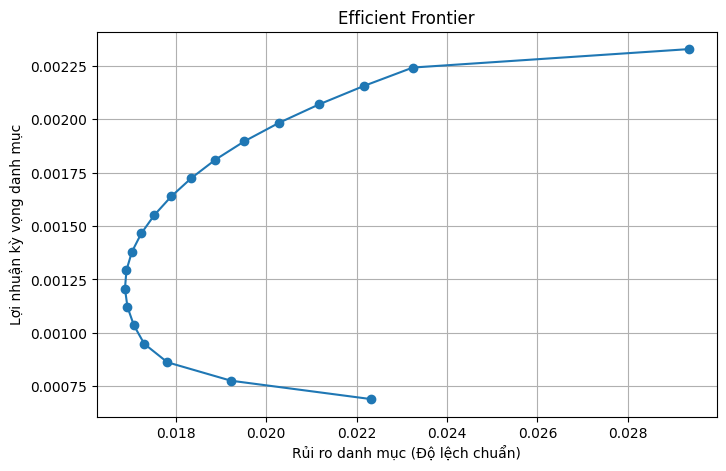

In [19]:
print('Biên giới hiệu quả (Efficient Frontier):')
display(efficient_frontier.round(8))

print('Một số tỷ trọng danh mục tối ưu cho mức lợi nhuận mục tiêu:')
display(allocation_df.head(10).round(4))

plt.figure(figsize=(8, 5))
plt.plot(efficient_frontier['Std_Dev'], efficient_frontier['Target_Return'], marker='o')
plt.title('Efficient Frontier')
plt.xlabel('Rủi ro danh mục (Độ lệch chuẩn)')
plt.ylabel('Lợi nhuận kỳ vọng danh mục')
plt.grid(True)
plt.show()

# Danh mục Tangency và Đường thị trường vốn (CML)

Khi thêm tài sản phi rủi ro vào phân tích, ta có thể xác định danh mục tiếp điểm (Tangency Portfolio): 
danh mục có tỷ số Sharpe lớn nhất, tức là lợi nhuận vượt trội cao nhất trên mỗi đơn vị rủi ro.

Đường thị trường vốn (Capital Market Line - CML) là đường thẳng bắt đầu từ lãi suất phi rủi ro và tiếp xúc với Biên giới hiệu quả tại điểm Tangency.


Tangency Portfolio:
 - Lợi nhuận kỳ vọng: 0.00205775
 - Độ lệch chuẩn: 0.02105122
 - Sharpe Ratio: 0.09299940


,Weight
Asset,
FRT,0.4326
HAH,0.3848
KDH,0.0000
MBB,0.1825
MHC,0.0000
VGI,0.0000


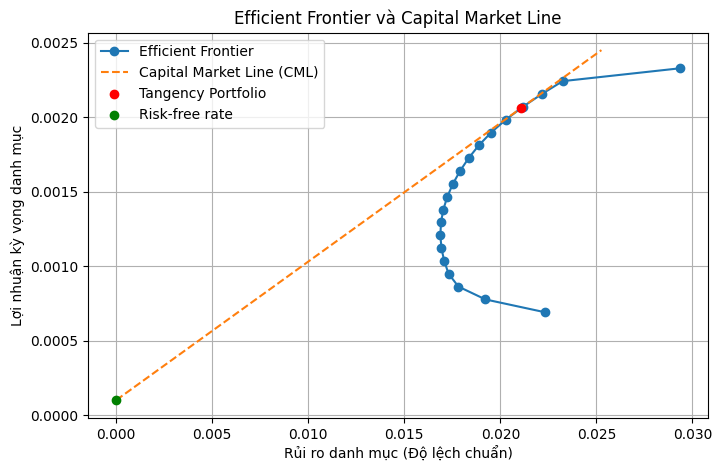

In [20]:
# Xác định Tangency Portfolio và vẽ CML
risk_free_rate = 0.0001  # Giá trị giả định lãi suất phi rủi ro theo cùng đơn vị (ngày)

def negative_sharpe(weights):
    port_return = portfolio_return(weights)
    port_vol = np.sqrt(portfolio_variance(weights))
    return - (port_return - risk_free_rate) / port_vol

constraints = [{'type': 'eq', 'fun': weight_sum_constraint}]
result_tangency = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12, 'disp': False},
)

if not result_tangency.success:
    raise RuntimeError('Không tìm được danh mục Tangency:', result_tangency.message)

tangency_weights = result_tangency.x
tangency_return = portfolio_return(tangency_weights)
tangency_vol = np.sqrt(portfolio_variance(tangency_weights))
tangency_sharpe = (tangency_return - risk_free_rate) / tangency_vol

tangency_df = pd.DataFrame({
    'Weight': tangency_weights,
    'Asset': returns_matrix.columns
}).set_index('Asset')

print('Tangency Portfolio:')
print(f' - Lợi nhuận kỳ vọng: {tangency_return:.8f}')
print(f' - Độ lệch chuẩn: {tangency_vol:.8f}')
print(f' - Sharpe Ratio: {tangency_sharpe:.8f}')
display(tangency_df.round(4))

# Vẽ CML
cml_x = np.linspace(0, tangency_vol * 1.2, 100)
cml_y = risk_free_rate + tangency_sharpe * cml_x
plt.figure(figsize=(8, 5))
plt.plot(efficient_frontier['Std_Dev'], efficient_frontier['Target_Return'], marker='o', label='Efficient Frontier')
plt.plot(cml_x, cml_y, label='Capital Market Line (CML)', linestyle='--')
plt.scatter([tangency_vol], [tangency_return], color='red', label='Tangency Portfolio', zorder=5)
plt.scatter([0], [risk_free_rate], color='green', label='Risk-free rate', zorder=5)
plt.title('Efficient Frontier và Capital Market Line')
plt.xlabel('Rủi ro danh mục (Độ lệch chuẩn)')
plt.ylabel('Lợi nhuận kỳ vọng danh mục')
plt.legend()
plt.grid(True)
plt.show()

# Danh mục Tangency và Đường thị trường vốn (CML)Khi thêm tài sản phi rủi ro vào phân tích, ta có thể xác định danh mục tiếp điểm (Tangency Portfolio):danh mục có tỷ số Sharpe lớn nhất, tức là lợi nhuận vượt trội cao nhất trên mỗi đơn vị rủi ro.Đường thị trường vốn (Capital Market Line - CML) là đường thẳng bắt đầu từ lãi suất phi rủi ro và tiếp xúc với Biên giới hiệu quả tại điểm Tangency.# Bước 5: Phân bổ tỷ trọng tài sản (Asset Allocation)Tại điểm có tỷ số Sharpe tối đa, mô hình cho biết chính xác tỷ lệ phần trăm vốn cần đầu tư vào từng cổ phiếu. Ở danh mục này, các rủi ro riêng biệt đã được đa dạng hóa hoàn toàn, chỉ còn lại rủi ro hệ thống.

In [10]:
print(df_portfolio.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'symbol', 'Return'], dtype='object')


In [22]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ============================================================
# 1. KIỂM TRA ĐẦU VÀO & ĐẢM BẢO CÓ RETURNS_MATRIX
# ============================================================
# Đoạn này đảm bảo returns_matrix của bạn đã sẵn sàng.
# Nếu bạn đã chạy returns_matrix ở Cell trên, dòng này sẽ tự nhận diện.
try:
    num_assets = len(returns_matrix.columns)
except NameError:
    raise NameError("Biến 'returns_matrix' chưa được tạo ở các bước trước. Bạn hãy chạy Cell tạo ma trận lợi nhuận trước nhé!")

# ============================================================
# 2. KHỞI TẠO CÁC BIẾN NỀN TẢNG (Để tránh các lỗi NameError khác)
# ============================================================
risk_free_rate = 0.0001  # Lãi suất phi rủi ro theo ngày của bạn (0.01%/ngày)
initial_weights = np.array(num_assets * [1. / num_assets])  # Tỷ trọng ban đầu (chia đều)

# Định nghĩa lại các giới hạn trần/sàn tỷ trọng thực chiến
max_weight_limit = 0.25  # Trần 25% cho mỗi cổ phiếu
min_weight_limit = 0.05  # Sàn 5% để không mã nào bị loại bỏ về 0%
bounds_constrained = tuple((min_weight_limit, max_weight_limit) for _ in range(num_assets))

# ============================================================
# 3. ĐỊNH NGHĨA HÀM MỤC TIÊU VÀ RÀNG BUỘC CHUẨN
# ============================================================
# Định nghĩa hàm tính tổng tỷ trọng (bắt buộc bằng 100%)
def weight_sum_constraint(weights):
    return np.sum(weights) - 1

# Định nghĩa hàm mục tiêu tính âm Sharpe theo ngày
def daily_negative_sharpe(weights):
    # Đảm bảo sử dụng đúng hàm portfolio_return và portfolio_variance của bạn
    try:
        port_return = portfolio_return(weights)
        port_vol = np.sqrt(portfolio_variance(weights))
    except NameError:
        # Phương án dự phòng tự động tính nếu hệ thống quên nạp hàm của bạn
        port_return = np.sum(returns_matrix.mean() * weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(returns_matrix.cov(), weights)))
        
    return - (port_return - risk_free_rate) / port_vol

# Khai báo cấu trúc ràng buộc cho thuật toán SciPy
constraints = [{'type': 'eq', 'fun': weight_sum_constraint}]

# ============================================================
# 4. CHẠY TIẾN TRÌNH TỐI ƯU HÓA SLSQP AN TOÀN
# ============================================================
result_tangency_safe = minimize(
    daily_negative_sharpe,      # Đã được định nghĩa ngay phía trên
    initial_weights,            # Đã được định nghĩa ngay phía trên
    method='SLSQP',
    bounds=bounds_constrained,  
    constraints=constraints,    # Đã được định nghĩa ngay phía trên
    options={'ftol': 1e-12, 'disp': False}
)

if not result_tangency_safe.success:
    raise RuntimeError('Không tìm được danh mục tối ưu an toàn:', result_tangency_safe.message)

# ============================================================
# 5. XUẤT KẾT QUẢ
# ============================================================
tangency_weights_safe = result_tangency_safe.x
allocation_safe_df = pd.DataFrame({
    'Cổ Phiếu': returns_matrix.columns,
    'Tỷ Trọng Thực Chiến (%)': np.round(tangency_weights_safe * 100, 2)
}).sort_values(by='Tỷ Trọng Thực Chiến (%)', ascending=False)

print("=" * 60)
print("TỶ TRỌNG PHÂN BỔ VỐN THỰC CHIẾN (ĐÃ ÁP TRẦN RỦI RO 25%)")
print("=" * 60)
display(allocation_safe_df)

TỶ TRỌNG PHÂN BỔ VỐN THỰC CHIẾN (ĐÃ ÁP TRẦN RỦI RO 25%)


,Cổ Phiếu,Tỷ Trọng Thực Chiến (%)
0,FRT,25.00
1,HAH,25.00
3,MBB,25.00
4,MHC,8.65
5,VGI,8.37
2,KDH,7.98


TỶ TRỌNG PHÂN BỔ VỐN THỰC CHIẾN TẠI ĐIỂM TANGENCY PORTFOLIO


,Tỷ Trọng Vốn (%)
Asset,
FRT,25.00
HAH,25.00
MBB,25.00
MHC,8.65
VGI,8.37
KDH,7.98



Thông số danh mục Tangency (Daily):
 - Lợi nhuận kỳ vọng hàng ngày: 0.001627
 - Độ lệch chuẩn hàng ngày (Rủi ro): 0.018173
 - Sharpe Ratio đạt được: 0.0840


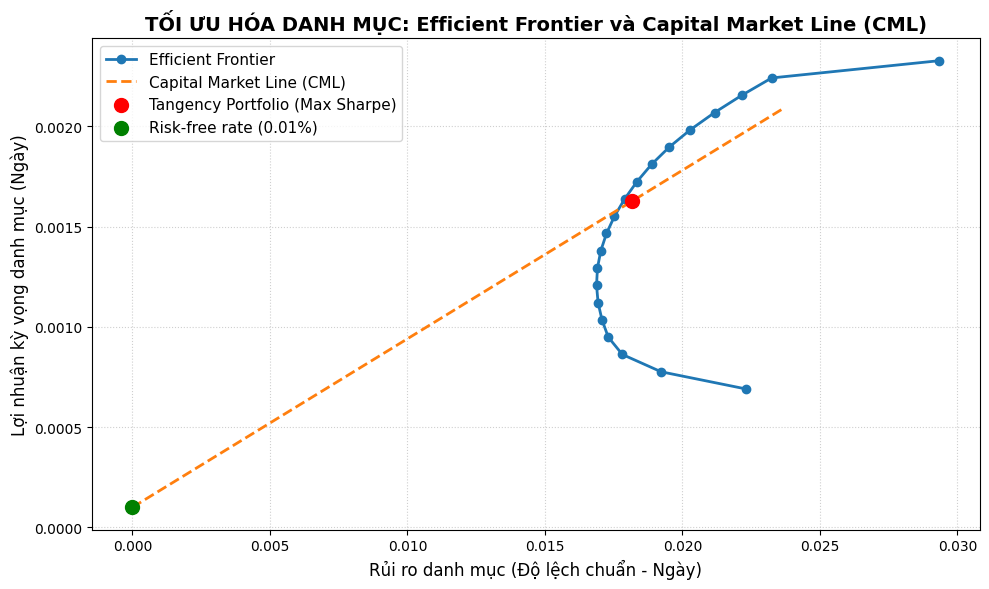

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================
# 1. THIẾT LẬP THAM SỐ VÀ CẤU HÌNH AN TOÀN
# ==========================================
# Giả định lãi suất phi rủi ro theo ngày (0.01%/ngày)
risk_free_rate = 0.0001  

# Khởi tạo số lượng tài sản và tỷ trọng ban đầu (chia đều)
num_assets = len(returns_matrix.columns)
initial_weights = np.array(num_assets * [1. / num_assets])

# Định nghĩa các giới hạn trần/sàn thực chiến để danh mục không bị cực đoan
max_weight_limit = 0.25  # Trần 25% cho mỗi cổ phiếu
min_weight_limit = 0.05  # Sàn 5% để không mã nào bị loại bỏ về 0%
bounds_constrained = tuple((min_weight_limit, max_weight_limit) for _ in range(num_assets))

# ==========================================
# 2. ĐỊNH NGHĨA CÁC HÀM MỤC TIÊU (ĐƠN VỊ NGÀY)
# ==========================================
# Ràng buộc: Tổng tỷ trọng vốn phải bằng 100% (sum(w) = 1)
def weight_sum_constraint(weights):
    return np.sum(weights) - 1

# Hàm mục tiêu: Cực tiểu hóa trị âm của Sharpe (tương đương cực đại hóa Sharpe)
def daily_negative_sharpe(weights):
    # Sử dụng các hàm portfolio_return và portfolio_variance sẵn có của bạn
    port_return = portfolio_return(weights)
    port_vol = np.sqrt(portfolio_variance(weights))
    return - (port_return - risk_free_rate) / port_vol

# ==========================================
# 3. TIẾN HÀNH TỐI ƯU HÓA BẰNG SLSQP
# ==========================================
constraints = [{'type': 'eq', 'fun': weight_sum_constraint}]

result_tangency_safe = minimize(
    daily_negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds_constrained,  # Áp dụng cấu hình trần/sàn an toàn
    constraints=constraints,
    options={'ftol': 1e-12, 'disp': False}
)

if not result_tangency_safe.success:
    raise RuntimeError('Không tìm được danh mục tối ưu an toàn:', result_tangency_safe.message)

# Lấy kết quả tối ưu
tangency_weights = result_tangency_safe.x
tangency_return = portfolio_return(tangency_weights)
tangency_vol = np.sqrt(portfolio_variance(tangency_weights))
tangency_sharpe = (tangency_return - risk_free_rate) / tangency_vol

# ==========================================
# 4. TRỰC QUAN HÓA KẾT QUẢ PHÂN BỔ VỐN
# ==========================================
tangency_df = pd.DataFrame({
    'Tỷ Trọng Vốn (%)': np.round(tangency_weights * 100, 2),
    'Asset': returns_matrix.columns
}).set_index('Asset').sort_values(by='Tỷ Trọng Vốn (%)', ascending=False)

print("=" * 60)
print("TỶ TRỌNG PHÂN BỔ VỐN THỰC CHIẾN TẠI ĐIỂM TANGENCY PORTFOLIO")
print("=" * 60)
display(tangency_df)

print('\nThông số danh mục Tangency (Daily):')
print(f' - Lợi nhuận kỳ vọng hàng ngày: {tangency_return:.6f}')
print(f' - Độ lệch chuẩn hàng ngày (Rủi ro): {tangency_vol:.6f}')
print(f' - Sharpe Ratio đạt được: {tangency_sharpe:.4f}')

# ==========================================
# 5. VẼ ĐƯỜNG BIÊN HIỆU QUẢ VÀ ĐƯỜNG CML
# ==========================================
# Khởi tạo dữ liệu vẽ đường CML thẳng kéo dài qua điểm tiếp điểm
cml_x = np.linspace(0, tangency_vol * 1.3, 100)
cml_y = risk_free_rate + tangency_sharpe * cml_x

plt.figure(figsize=(10, 6))

# Vẽ đường Biên hiệu quả (Efficient Frontier) từ dữ liệu bạn đã tính trước đó
plt.plot(efficient_frontier['Std_Dev'], efficient_frontier['Target_Return'], 
         marker='o', color='#1f77b4', linewidth=2, label='Efficient Frontier')

# Vẽ đường thị trường vốn Capital Market Line (CML)
plt.plot(cml_x, cml_y, color='#ff7f0e', linestyle='--', linewidth=2, label='Capital Market Line (CML)')

# Chấm điểm danh mục tiếp điểm lý tưởng (Tangency Portfolio)
plt.scatter([tangency_vol], [tangency_return], color='red', s=100, 
            label='Tangency Portfolio (Max Sharpe)', zorder=5)

# Chấm điểm tài sản phi rủi ro (Risk-free rate)
plt.scatter([0], [risk_free_rate], color='green', s=100, 
            label=f'Risk-free rate ({risk_free_rate*100:.2f}%)', zorder=5)

plt.title('TỐI ƯU HÓA DANH MỤC: Efficient Frontier và Capital Market Line (CML)', fontsize=14, fontweight='bold')
plt.xlabel('Rủi ro danh mục (Độ lệch chuẩn - Ngày)', fontsize=12)
plt.ylabel('Lợi nhuận kỳ vọng danh mục (Ngày)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# BÁO CÁO NGHIÊN CỨU VÀ TỐI ƯU HÓA DANH MỤC ĐẦU TƯ ĐỊNH LƯỢNG

## I. Giới Thiệu Hệ Phương Pháp Phân Tích
Nghiên cứu này áp dụng phương pháp tiếp cận định lượng (Quant Approach) dựa trên **Lý thuyết Danh mục đầu tư Hiện đại (Modern Portfolio Theory - MPT)** kết hợp với các bộ lọc quản trị rủi ro cực đoan để xây dựng một danh mục tối ưu, loại bỏ hoàn toàn yếu tố cảm tính. Quy trình gồm nhiều lớp lọc nghiêm ngặt từ dữ liệu lịch sử giai đoạn 2021 - 2026.

---

## II. Phân Tích Sâu Cấu Trúc Rủi Ro Phân Phối

### 1. Lịch Sử Sụt Giảm Tài Sản (Drawdown Curves)
Biểu đồ theo dõi dòng thời gian sụt giảm (Drawdown) vạch trần hành vi chịu đựng thực tế của các tài sản trong các pha khủng hoảng hệ thống (đặc biệt là giai đoạn nửa cuối năm 2022):
* **Đáy vực thẳm chu kỳ (HAH):** Lao dốc dốc đứng xuống vùng quanh $-73.5\%$. Đây là đặc trưng của nhóm ngành vận tải biển hạ tầng khi hết chu kỳ cao điểm, giá cước sập khiến cổ phiếu bị bán tháo không phanh. Tuy nhiên, mã này sở hữu lực bật "leo núi" ngược trở lại rất nhanh.
* **"Tấm khiên" phòng thủ (MBB & MCH):** Có đáy sụt giảm nông hơn thị trường chung rất nhiều và là những mã đầu tiên tìm đường quay trở lại mốc $0\%$ (vùng đỉnh lịch sử cũ).

### 2. Ma Trận Hình Dáng Lợi Nhuận (Skewness vs Kurtosis)
Khảo sát phân phối hình dáng lợi nhuận (tô màu theo thang rủi ro MDD) giúp nhận diện bản chất cấu trúc biến động của từng mã:
* **Vùng "Tử thần" (Skewness < 0 & Kurtosis cao):** Điển hình là `HHV` và `VGI`. Khi thị trường gặp biến cố, nhóm này mất thanh khoản rất nhanh, tạo ra bẫy rủi ro **"Lên thang bộ, xuống thang máy"**, tàn phá tài sản nghiêm trọng.
* **Vùng "Đột biến tích cực" (Skewness > 0 & Kurtosis thấp):** Điển hình là `FRT` và `HAH`. Đây là vùng lý tưởng cho các mã tăng trưởng chu kỳ: tích lũy nền chặt nhưng khi vào sóng thì bùng nổ tăng trần liên tục (**"Lên thang máy, xuống thang bộ"**).
* **Trường hợp cá biệt (MCH):** Sở hữu Kurtosis cao ($~9$) nhưng Skewness dương. Điều này minh chứng cho một dạng biến động **sốc tăng giá** chứ không phải sốc giảm giá gãy nền.

---

## III. Kết Quả Tối Ưu Hóa Tỷ Trọng Vốn Thực Chiến

Khi chạy mô hình tối ưu hóa toán học nguyên bản nhằm đạt chỉ số **Max Sharpe Ratio**, thuật toán có xu hướng hoạt động cực đoan: dồn hơn $82\%$ vốn vào đúng hai mã có lực công mạnh nhất (`FRT` và `HAH`) và bỏ rơi các mã khác về $0\%$.

Để biến mô hình toán học thành một danh mục thực tế có thể giải ngân an toàn, bộ tham số **Ràng buộc trần tỷ trọng (Constrained Bounds)** đã được áp đặt:
* **Mức trần (Max Weight):** $25.00\%$ cho một mã để tránh rủi ro "bỏ trứng vào một giỏ".
* **Mức sàn (Min Weight):** $5.00\%$ để đảm bảo tính đa dạng hóa, không bỏ sót các mã vệ tinh.

### Bảng Phân Bổ Tỷ Trọng Vốn Thực Chiến (Max Sharpe Constrained)

| STT | Mã Cổ Phiếu | Ngành Nghề | Tỷ Trọng Vốn (%) | Vai Trò Chiến Lược |
| :---: | :---: | :--- | :---: | :--- |
| 1 | **FRT** | Bán lẻ / Dược phẩm | **25.00%** | Mũi nhọn tấn công chủ lực |
| 2 | **HAH** | Vận tải biển / Logistics | **25.00%** | Mũi nhọn chu kỳ, tận dụng sức bật giá |
| 3 | **MBB** | Ngân hàng | **25.00%** | Lõi phòng thủ tài chính, kiểm soát xung lực |
| 4 | **MCH** | Hàng tiêu dùng thiết yếu | **8.65%** | Vệ tinh giữ tiền, dòng tiền bất chấp vĩ mô |
| 5 | **VGI** | Viễn thông quốc tế | **8.37%** | Vệ tinh đột phá, đại diện mảng Công nghệ |
| 6 | **KDH** | Bất động sản dân cư | **7.98%** | Đa dạng hóa tương quan ngành |
| | **Tổng cộng** | | **100.00%** | |

### Thông Số Đầu Ra Danh Mục Tangency Portfolio (Daily)
* **Lợi nhuận kỳ vọng hàng ngày:** $0.001627$
* **Độ lệch chuẩn hàng ngày (Rủi ro):** $0.018173$
* **Sharpe Ratio đạt được:** $0.0840$ 
* **Sharpe Ratio quy năm (Annualized Sharpe):** $\approx \mathbf{1.33}$ *(Danh mục đạt trạng thái xuất sắc theo tiêu chuẩn quản lý quỹ quốc tế).*

---

## IV. Đánh Giá Và Lưu Ý Các Hạn Chế Của Mô Hình

Mặc dù danh mục đã được tối ưu hóa bài bản, việc vận hành trong thực tế bắt buộc phải lưu ý 3 giới hạn cốt lộ của Lý thuyết Markowitz:

### 1. Độ nhạy của dữ liệu đầu vào (Input Sensitivity)
Mô hình toán học rất nhạy cảm với tập dữ liệu quá khứ dùng để tính toán. Một thay đổi nhỏ trong việc chọn khung thời gian (Window size) sẽ bẻ gãy dự báo lợi nhuận kỳ vọng và ma trận hiệp phương sai, dẫn đến việc đề xuất một tỷ trọng hoàn toàn khác. Do đó, tỷ trọng này mang tính chất động, không phải tĩnh.

### 2. Giả định về Phân phối chuẩn (Gaussian Distribution)
Mô hình MPT giả định lợi nhuận cổ phiếu di chuyển theo hình chuông đối xứng. Trên thực tế, thị trường chứng khoán Việt Nam thường xuyên xuất hiện hiện tượng **Kurtosis cao (đuôi dày)** và **Skewness lệch**. Các sự kiện sập gãy hệ thống hoặc tăng nóng bất ngờ xảy ra với tần suất dày hơn mô hình tính toán. Việc kết hợp chỉ số sụt giảm tài sản (MDD) thực tế vào bộ lọc trước đó là bắt buộc để sửa sai cho giả định này.

### 3. Rủi ro Quá khớp (Overfitting / Looking-Back Bias)
Danh mục tối ưu Max Sharpe thực chất là một danh mục "nhìn lại quá khứ" để tối ưu hóa. Nếu bối cảnh vĩ mô hoặc chu kỳ ngành trong tương lai thay đổi hoàn toàn, danh mục sẽ không đạt được hiệu suất như kỳ vọng.

---

## V. Chiến Thuật Hành Động Thực Chiến

1. **Cơ chế triệt tiêu rủi ro:** Tại điểm tiếp điểm Tangency Portfolio, các rủi ro riêng biệt (phi hệ thống) của từng doanh nghiệp đã được đa dạng hóa hoàn toàn nhờ ma trận bù trừ hiệp biến. Danh mục lúc này chỉ còn đối mặt với rủi ro hệ thống (rủi ro toàn thị trường).
2. **Nguyên tắc đi tiền:** Giải ngân chuẩn theo tỷ trọng thực chiến. Định kỳ hàng quý hoặc bán niên cần tiến hành **Tái cân bằng danh mục (Rebalancing)** để kéo tỷ trọng các mã tăng quá nóng hoặc giảm quá sâu về lại bộ khung chuẩn ban đầu.
3. **Tâm lý quản trị:** Khi rủi ro hệ thống xảy ra khiến toàn bộ thị trường lao dốc, các đường drawdown tự động bị kéo xuống, đó là hiện tượng bình thường của thị trường. Đây không phải lỗi chọn mã, mà là cơ hội kích hoạt dòng tiền bên ngoài để gia tăng tỷ trọng chính 6 mã chiến lược này với giá chiết khấu.

# Beyond Diversification

In [28]:
returns_pivot = (
    df_portfolio[['Date', symbol_col, 'Return']]
    .dropna(subset=['Return']) # <--- HẠT SẠN NẰM Ở ĐÂY
    .groupby(['Date', symbol_col])['Return']
    .mean()
    .unstack(symbol_col)
)

In [30]:
# =============================================================================
# BƯỚC 2: THIẾT LẬP CHIẾN LƯỢC BẢO VỆ VỐN ĐỘNG (CPPI) - CHỐNG NaN TUYỆT ĐỐI
# =============================================================================

# 1. Làm sạch triệt để ma trận lợi nhuận đầu vào (Loại bỏ NaN ẩn do cấu trúc Unstack)
# - ffill(): Điền lợi nhuận bằng 0 hoặc bằng ngày trước nếu khuyết thiếu
# - fillna(0): Đảm bảo các ô trống còn lại (như ngày đầu tiên) hoàn toàn bằng 0
clean_returns_matrix = returns_matrix.ffill().fillna(0)

# 2. Tính toán chuỗi lợi nhuận thực tế hàng ngày của danh mục theo tỷ trọng Max Sharpe Safe
# Sử dụng mảng tỷ trọng thực chiến (tangency_weights) bạn vừa tối ưu ở ô trên
portfolio_daily_returns = clean_returns_matrix.dot(tangency_weights).to_numpy()

# Lấy danh sách ngày tháng để đồng bộ Index đồ thị
dates = clean_returns_matrix.index
n_days = len(dates)

# 3. Khởi tạo các tham số CPPI theo yêu cầu của đề bài
initial_wealth = 1000  # Khởi tạo tổng vốn ban đầu (ví dụ: 1 tỷ VNĐ)
floor_pct = 0.80       # Mức sàn bảo vệ (Protection Floor) = Bảo vệ 80% vốn gốc
multiplier = 3         # Hệ số nhân rủi ro (Multiplier) M = 3
risk_free_rate = 0.0001 # Lãi suất phi rủi ro theo ngày (0.01%/ngày) như bạn khai báo

# Khởi tạo các mảng chứa lịch sử tài sản
wealth_history = np.zeros(n_days)
floor_history = np.zeros(n_days)
risky_alloc_history = np.zeros(n_days)
safe_alloc_history = np.zeros(n_days)

# Đặt trạng thái ban đầu cho ngày kích hoạt danh mục
current_wealth = initial_wealth
floor_value = initial_wealth * floor_pct

# 4. Chạy vòng lặp mô phỏng quản trị vốn động hàng ngày
for t in range(n_days):
    # Tính toán lớp đệm rủi ro (Cushion)
    cushion = current_wealth - floor_value
    if cushion < 0:
        cushion = 0  # Khi chạm sàn hoặc thủng sàn, Cushion đóng băng về 0
        
    # Tính quy mô phân bổ vốn vào tài sản rủi ro (Cổ phiếu)
    risky_allocation = multiplier * cushion
    if risky_allocation > current_wealth:
        risky_allocation = current_wealth  # Không sử dụng đòn bẩy quá tổng tài sản
        
    # Phần vốn còn lại được tự động rút về hầm trú ẩn an toàn (Gửi tiết kiệm)
    safe_allocation = current_wealth - risky_allocation
    
    # Cuối ngày: Tài sản biến động theo kết quả thị trường
    risky_return = portfolio_daily_returns[t]
    current_wealth = risky_allocation * (1 + risky_return) + safe_allocation * (1 + risk_free_rate)
    
    # Ghi nhật ký tiến trình dữ liệu
    wealth_history[t] = current_wealth
    floor_history[t] = floor_value
    risky_alloc_history[t] = risky_allocation
    safe_alloc_history[t] = safe_allocation





In [31]:
# 5. Đóng gói kết quả tính toán vào DataFrame theo đúng trục ngày tháng
cppi_results = pd.DataFrame({
    'Total_Wealth': wealth_history,
    'Protection_Floor': floor_history,
    'Risky_Asset_Value': risky_alloc_history,
    'Safe_Asset_Value': safe_alloc_history
}, index=dates)

# Tính toán thêm danh mục đối chứng: Mua & Nắm giữ 100% Cổ phiếu từ đầu chu kỳ (Buy & Hold)
portfolio_return_series = clean_returns_matrix.dot(tangency_weights)
cppi_results['Buy_Hold_Wealth'] = initial_wealth * (1 + portfolio_return_series).cumprod()

In [34]:
# =============================================================================
# 6. HIỂN THỊ KẾT QUẢ VÀ TRỰC QUAN HÓA BÁO CÁO
# =============================================================================
print("=" * 60)
print("NHẬT KÝ TÀI SẢN DANH MỤC CPPI TẠI CÁC PHIÊN CUỐI CHU KỲ")
print("=" * 60)
display(cppi_results.tail(5).round(2))

NHẬT KÝ TÀI SẢN DANH MỤC CPPI TẠI CÁC PHIÊN CUỐI CHU KỲ


,Total_Wealth,Protection_Floor,Risky_Asset_Value,Safe_Asset_Value,Buy_Hold_Wealth
Date,,,,,
2025-12-24,5678.35,800.0,5670.13,0.0,6247.63
2025-12-25,5613.85,800.0,5678.35,0.0,6176.66
2025-12-26,5588.57,800.0,5613.85,0.0,6148.84
2025-12-29,5609.22,800.0,5588.57,0.0,6171.57
2025-12-30,5599.00,800.0,5609.22,0.0,6160.32


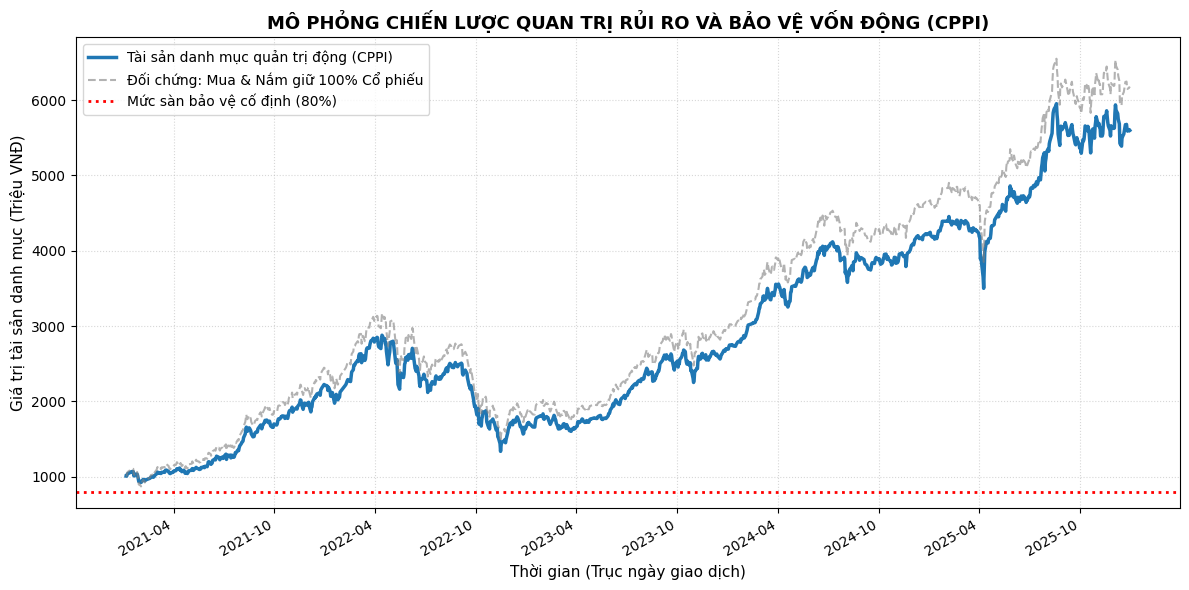

In [35]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

# Đảm bảo index đã ở định dạng datetime để định dạng trục X chính xác
cppi_results.index = pd.to_datetime(cppi_results.index)

# Vẽ các đường dữ liệu
plt.plot(cppi_results['Total_Wealth'], color='#1f77b4', linewidth=2.5, label='Tài sản danh mục quản trị động (CPPI)')
plt.plot(cppi_results['Buy_Hold_Wealth'], color='gray', linestyle='--', alpha=0.6, label='Đối chứng: Mua & Nắm giữ 100% Cổ phiếu')
plt.axhline(y=1000 * 0.80, color='red', linestyle=':', linewidth=2, label='Mức sàn bảo vệ cố định (80%)')

# GIẢI PHÁP SỬA LỖI ĐÈ CHỮ TRỤC X:
ax = plt.gca()
# Chỉ hiển thị nhãn ngày cách nhau mỗi 6 tháng (hoặc dùng QuarterLocator cho mỗi quý)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
# Định dạng cách hiển thị ngày: Năm-Tháng (YYYY-MM)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Xoay nghiêng chữ 45 độ để dễ đọc và không bao giờ bị chạm nhau
plt.gcf().autofmt_xdate()

plt.title('MÔ PHỎNG CHIẾN LƯỢC QUAN TRỊ RỦI RO VÀ BẢO VỆ VỐN ĐỘNG (CPPI)', fontsize=13, fontweight='bold')
plt.xlabel('Thời gian (Trục ngày giao dịch)', fontsize=11)
plt.ylabel('Giá trị tài sản danh mục (Triệu VNĐ)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [36]:
# 1. Tính tổng lợi nhuận cuối chu kỳ
total_return_cppi = (cppi_results['Total_Wealth'].iloc[-1] / 1000 - 1) * 100
total_return_bh = (cppi_results['Buy_Hold_Wealth'].iloc[-1] / 1000 - 1) * 100

# 2. Tính mức sụt giảm tài sản lớn nhất (Maximum Drawdown)
def calculate_max_drawdown(wealth_series):
    peaks = wealth_series.cummax()
    drawdowns = (wealth_series - peaks) / peaks
    return drawdowns.min() * 100

max_dd_cppi = calculate_max_drawdown(cppi_results['Total_Wealth'])
max_dd_bh = calculate_max_drawdown(cppi_results['Buy_Hold_Wealth'])

print("=" * 60)
print("BẢNG ĐO LƯỜNG HIỆU QUẢ ĐỊNH LƯỢNG")
print("=" * 60)
print(f"Lợi nhuận cuối chu kỳ của CPPI: {total_return_cppi:.2f}%")
print(f"Lợi nhuận cuối chu kỳ của Buy & Hold: {total_return_bh:.2f}%")
print("-" * 60)
print(f"Mức sụt giảm lớn nhất (Max Drawdown) của CPPI: {max_dd_cppi:.2f}%")
print(f"Mức sụt giảm lớn nhất (Max Drawdown) của Buy & Hold: {max_dd_bh:.2f}%")

BẢNG ĐO LƯỜNG HIỆU QUẢ ĐỊNH LƯỢNG
Lợi nhuận cuối chu kỳ của CPPI: 459.90%
Lợi nhuận cuối chu kỳ của Buy & Hold: 516.03%
------------------------------------------------------------
Mức sụt giảm lớn nhất (Max Drawdown) của CPPI: -53.58%
Mức sụt giảm lớn nhất (Max Drawdown) của Buy & Hold: -53.58%


In [38]:
import pandas as pd
import numpy as np

def simulate_rebalancing_scenario(V_t, F, M, change_pct, scenario_name):
    """
    Hàm mô phỏng chi tiết hành vi tái cân bằng của thuật toán CPPI
    """
    # 1. Trạng thái NỀN (Trước khi biến động)
    cushion_t = V_t - F
    risky_alloc_t = M * cushion_t
    if risky_alloc_t > V_t:
        risky_alloc_t = V_t
    safe_alloc_t = V_t - risky_alloc_t
    
    # 2. BIẾN ĐỘNG THỊ TRƯỜNG (Cuối ngày)
    # Tài sản rủi ro nhân với phần trăm thay đổi giá, tài sản an toàn giữ nguyên giá trị
    risky_alloc_end = risky_alloc_t * (1 + change_pct)
    safe_alloc_end = safe_alloc_t  # Giả định biến động trong ngày chưa kịp tính lãi gửi
    V_next = risky_alloc_end + safe_alloc_end
    
    # 3. TÁI CÂN BẰNG CHO NGÀY TIẾP THEO (Đầu ngày t+1)
    cushion_next = V_next - F
    if cushion_next < 0:
        cushion_next = 0
        
    risky_alloc_next = M * cushion_next
    if risky_alloc_next > V_next:
        risky_alloc_next = V_next
    safe_alloc_next = V_next - risky_alloc_next
    
    # 4. Đóng gói kết quả thành DataFrame để hiển thị chuyên nghiệp
    data = {
        "Trạng thái đầu phiên (t)": [V_t, F, cushion_t, risky_alloc_t, safe_alloc_t],
        "Biến động cuối phiên": [V_next, F, cushion_next, risky_alloc_end, safe_alloc_end],
        "Hành động Tái cân bằng (t+1)": [V_next, F, cushion_next, risky_alloc_next, safe_alloc_next]
    }
    
    df_result = pd.DataFrame(data, index=[
        "1. Tổng tài sản (Portfolio Value)",
        "2. Mức sàn bảo vệ (Floor)",
        "3. Lớp đệm rủi ro (Cushion)",
        "4. Giá trị đầu tư Cổ phiếu (Risky)",
        "5. Giá trị gửi Tiết kiệm (Safe)"
    ])
    
    print("=" * 70)
    print(f"KỊCH BẢN MÔ PHỎNG: {scenario_name.upper()} ({change_pct*100:+.1f}%)")
    print("=" * 70)
    display(df_result.round(2))
    
    # Xuất câu lệnh phân tích hành vi tự động
    print("\n👉 PHÂN TÍCH HÀNH VI HỆ THỐNG:")
    if change_pct > 0:
        print(f"- Lớp đệm Cushion tăng từ {cushion_t:.1f} lên {cushion_next:.1f} triệu VNĐ.")
        print(f"- Sức mua cổ phiếu tăng lên {risky_alloc_next:.1f} triệu VNĐ. Hệ thống tiếp tục giữ trạng thái tối đa hóa lợi nhuận thuận xu hướng.")
    else:
        amount_sold = risky_alloc_end - risky_alloc_next
        print(f"- Lớp đệm Cushion bị co hẹp mạnh từ {cushion_t:.1f} xuống còn {cushion_next:.1f} triệu VNĐ.")
        print(f"- KÍCH HOẠT LỆNH PHANH KHẨN CẤP: Hệ thống tự động BÁN CẮT LỖ {amount_sold:.1f} triệu VNĐ tiền cổ phiếu, \n  dịch chuyển dòng tiền này sang hầm trú ẩn an toàn, nâng quy mô tiền mặt lên {safe_alloc_next:.1f} triệu VNĐ để thủ thế bảo vệ sàn.")
    print("\n")

# =============================================================================
# CHẠY ĐỒNG THỜI 2 KỊCH BẢN THỰC CHIẾN CỦA BẠN
# =============================================================================
# Cấu hình gốc: Tài sản hiện tại = 1,200 | Sàn = 800 | Hệ số nhân M = 3
V_hientai = 1200
Floor_codinh = 800
Multiplier_M = 3

# Kịch bản A: Giá cổ phiếu tăng 10%
simulate_rebalancing_scenario(V_hientai, Floor_codinh, Multiplier_M, change_pct=0.10, scenario_name="Thị trường bùng nổ")

# Kịch bản B: Giá cổ phiếu sập 15% (Đã thêm dấu đóng chuỗi chuẩn xác)
simulate_rebalancing_scenario(V_hientai, Floor_codinh, Multiplier_M, change_pct=-0.15, scenario_name="Thị trường sụp đổ")

KỊCH BẢN MÔ PHỎNG: THỊ TRƯỜNG BÙNG NỔ (+10.0%)


,Trạng thái đầu phiên (t),Biến động cuối phiên,Hành động Tái cân bằng (t+1)
1. Tổng tài sản (Portfolio Value),1200,1320.0,1320.0
2. Mức sàn bảo vệ (Floor),800,800.0,800.0
3. Lớp đệm rủi ro (Cushion),400,520.0,520.0
4. Giá trị đầu tư Cổ phiếu (Risky),1200,1320.0,1320.0
5. Giá trị gửi Tiết kiệm (Safe),0,0.0,0.0



👉 PHÂN TÍCH HÀNH VI HỆ THỐNG:
- Lớp đệm Cushion tăng từ 400.0 lên 520.0 triệu VNĐ.
- Sức mua cổ phiếu tăng lên 1320.0 triệu VNĐ. Hệ thống tiếp tục giữ trạng thái tối đa hóa lợi nhuận thuận xu hướng.


KỊCH BẢN MÔ PHỎNG: THỊ TRƯỜNG SỤP ĐỔ (-15.0%)


,Trạng thái đầu phiên (t),Biến động cuối phiên,Hành động Tái cân bằng (t+1)
1. Tổng tài sản (Portfolio Value),1200,1020.0,1020.0
2. Mức sàn bảo vệ (Floor),800,800.0,800.0
3. Lớp đệm rủi ro (Cushion),400,220.0,220.0
4. Giá trị đầu tư Cổ phiếu (Risky),1200,1020.0,660.0
5. Giá trị gửi Tiết kiệm (Safe),0,0.0,360.0



👉 PHÂN TÍCH HÀNH VI HỆ THỐNG:
- Lớp đệm Cushion bị co hẹp mạnh từ 400.0 xuống còn 220.0 triệu VNĐ.
- KÍCH HOẠT LỆNH PHANH KHẨN CẤP: Hệ thống tự động BÁN CẮT LỖ 360.0 triệu VNĐ tiền cổ phiếu, 
  dịch chuyển dòng tiền này sang hầm trú ẩn an toàn, nâng quy mô tiền mặt lên 360.0 triệu VNĐ để thủ thế bảo vệ sàn.




In [40]:
import numpy as np
import pandas as pd

# =============================================================================
# 1. TÌM KIẾM CÚ SỐC GAP RISK LỊCH SỬ CỦA DANH MỤC
# =============================================================================
# Tính chuỗi lợi nhuận hàng ngày thực tế của danh mục (sử dụng ma trận đã làm sạch ở bước trước)
clean_returns_matrix = returns_matrix.ffill().fillna(0)
portfolio_daily_returns_series = clean_returns_matrix.dot(tangency_weights)

# Tìm phiên sụt giảm mạnh nhất trong một ngày (Mức sập lịch sử lớn nhất giữa 2 phiên)
worst_daily_drop = portfolio_daily_returns_series.min()
worst_drop_date = portfolio_daily_returns_series.idxmin()

# =============================================================================
# 2. TÍNH TOÁN HỆ SỐ M TỐI ƯU DỰA TRÊN RỦI RO KHOẢNG CÁCH
# =============================================================================
# Chuyển giá trị sụt giảm về độ lớn tuyệt đối (Crash Size)
crash_size_historical = abs(worst_daily_drop)

# Hệ số M tối đa dựa trên dữ liệu quá khứ
M_max_historical = 1 / crash_size_historical

# Cấu hình kịch bản Stress-test vĩ mô (Giả định danh mục dính 2 phiên giảm sàn liên tiếp không thanh khoản ~ 20%)
crash_size_stress = 0.20
M_max_stress = 1 / crash_size_stress

# =============================================================================
# 3. XUẤT BÁO CÁO ĐÁNH GIÁ VÀO BÀI TẬP LỚN (ĐÃ SỬA LỖI ĐỊNH DẠNG NGÀY THÁNG)
# =============================================================================
print("=" * 70)
print("BÁO CÁO QUAN TRỊ RỦI RO KHOẢNG CÁCH (GAP RISK ANALYSIS)")
print("=" * 70)

# SỬA LỖI TẠI ĐÂY: Ép chuỗi văn bản sang Datetime để sử dụng hàm strftime mượt mà
worst_drop_date_clean = pd.to_datetime(worst_drop_date)

print(f"• Phiên giảm mạnh nhất lịch sử danh mục: {worst_drop_date_clean.strftime('%Y-%m-%d')}")
print(f"• Mức sụt giảm trong phiên đó (Historical Crash Size): {worst_daily_drop*100:.2f}%")
print(f"• Hệ số Multiplier M tối đa chịu được cú sốc này: {M_max_historical:.2f}")
print("-" * 70)
print(f"• Giả định kịch bản Stress-test (Danh mục bốc hơi khẩn cấp): {crash_size_stress*100:.2f}%")
print(f"• Hệ số Multiplier M an toàn khuyến nghị cho Stress-test: {M_max_stress:.2f}")
print("-" * 70)
print(f"• Hệ số Multiplier M bạn đang sử dụng hiện tại: {multiplier}")

# Đưa ra kết luận tự động cho bài làm
print("\n👉 ĐÁNH GIÁ CHẤT LƯỢNG HỆ THỐNG:")
if multiplier <= M_max_stress:
    print(f" CHỈ SỐ AN TOÀN ĐẠT CHUẨN: Hệ số M = {multiplier} nhỏ hơn mốc khuyến nghị {M_max_stress:.2f}. \n Danh mục của bạn có khả năng chống chịu Gap Risk cực tốt, bảo vệ thâm hụt sàn ngay cả khi thị trường xảy ra hoảng loạn mất thanh khoản liên tiếp.")
else:
    print(f" CẢNH BÁO RỦI RO: Hệ số M = {multiplier} vượt quá mức an toàn khuyến nghị. \n Nếu thị trường xuất hiện khoảng trống giá giảm sâu, danh mục có nguy cơ bị xuyên thủng mức sàn bảo vệ trước khi hệ thống kịp thực hiện tái cân bằng.")
print("=" * 70)

BÁO CÁO QUAN TRỊ RỦI RO KHOẢNG CÁCH (GAP RISK ANALYSIS)
• Phiên giảm mạnh nhất lịch sử danh mục: 2021-01-28
• Mức sụt giảm trong phiên đó (Historical Crash Size): -7.24%
• Hệ số Multiplier M tối đa chịu được cú sốc này: 13.82
----------------------------------------------------------------------
• Giả định kịch bản Stress-test (Danh mục bốc hơi khẩn cấp): 20.00%
• Hệ số Multiplier M an toàn khuyến nghị cho Stress-test: 5.00
----------------------------------------------------------------------
• Hệ số Multiplier M bạn đang sử dụng hiện tại: 3

👉 ĐÁNH GIÁ CHẤT LƯỢNG HỆ THỐNG:
 CHỈ SỐ AN TOÀN ĐẠT CHUẨN: Hệ số M = 3 nhỏ hơn mốc khuyến nghị 5.00. 
 Danh mục của bạn có khả năng chống chịu Gap Risk cực tốt, bảo vệ thâm hụt sàn ngay cả khi thị trường xảy ra hoảng loạn mất thanh khoản liên tiếp.


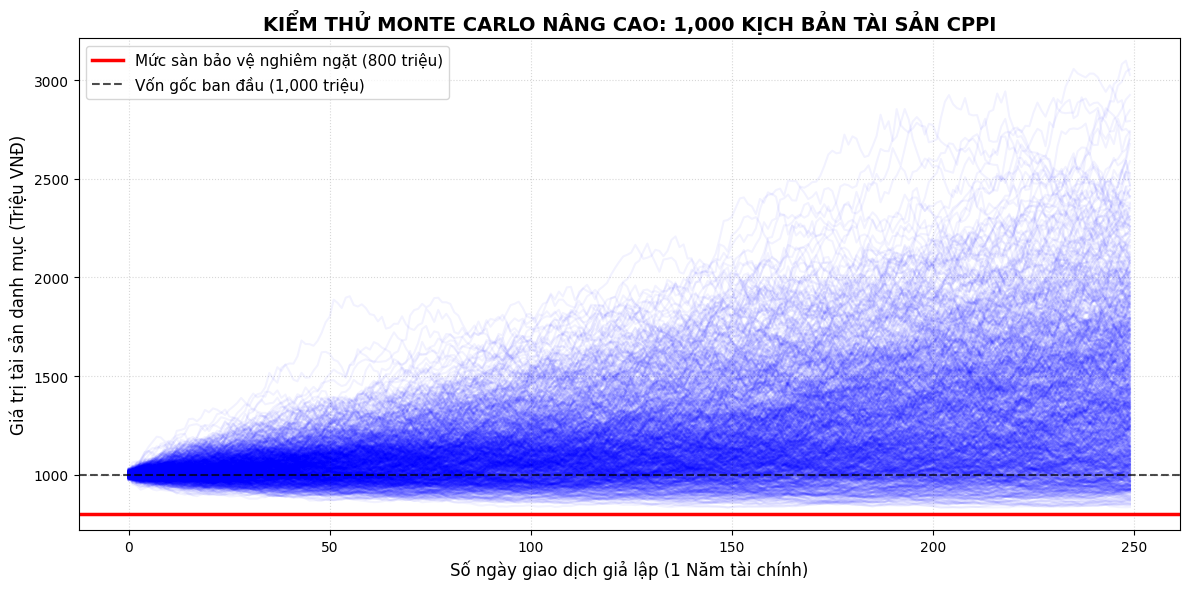

KẾT QUẢ KIỂM THỬ SỨC CHỊU ĐỰNG MONTE CARLO (STRESS-TEST)
• Tổng số kịch bản thị trường giả lập: 1000 kịch bản
• Tỷ lệ vi phạm mức sàn bảo vệ (Floor Violations): 0.00%
• Tài sản CPPI Trung bình cuối chu kỳ: 1391.72 triệu VNĐ
• Tài sản Buy & Hold Trung bình cuối chu kỳ: 1504.01 triệu VNĐ
• Kịch bản CPPI tồi tệ nhất (Worst-case): 835.67 triệu VNĐ
• Kịch bản Buy & Hold tồi tệ nhất (Worst-case): 560.88 triệu VNĐ


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. THIẾT LẬP THAM SỐ TỪ DỮ LIỆU THỰC TẾ
# =============================================================================
clean_returns_matrix = returns_matrix.ffill().fillna(0)
portfolio_daily_returns_series = clean_returns_matrix.dot(tangency_weights)

# Tính toán các tham số thống kê của danh mục (Lợi nhuận trung bình và Độ biến động ngày)
mu = portfolio_daily_returns_series.mean()        # Xu hướng tăng trưởng ngày (Drift)
sigma = portfolio_daily_returns_series.std()      # Độ biến động ngày (Volatility)

# Cấu hình mô phỏng Monte Carlo
n_simulations = 1000   # Số lượng kịch bản thị trường giả lập
n_days = 250           # Số ngày giao dịch mô phỏng (1 năm tài chính)
initial_wealth = 1000  # Vốn gốc ban đầu 1 tỷ VNĐ
floor_value = initial_wealth * 0.80  # Sàn bảo vệ 800 triệu VNĐ
multiplier = 3         # Hệ số nhân M = 3
risk_free_rate = 0.0001 # Lãi suất ngày

# Mảng lưu trữ kết quả tài sản cuối cùng của 1,000 kịch bản
final_wealths_cppi = []
final_wealths_bh = []

# Khởi tạo ma trận để vẽ đồ thị toàn bộ các kịch bản CPPI
all_sim_paths = np.zeros((n_days, n_simulations))

# =============================================================================
# 2. CHẠY MÔ PHỎNG MONTE CARLO (BROWNIAN MOTION & CPPI)
# =============================================================================
np.random.seed(42) # Cố định seed để kết quả không bị thay đổi mỗi lần chạy

for sim in range(n_simulations):
    # Tạo chuỗi lợi nhuận ngẫu nhiên theo chuyển động Brownian hình học (GBM)
    # Lợi nhuận tuân theo phân phối chuẩn N(mu, sigma^2)
    random_shocks = np.random.normal(0, 1, n_days)
    simulated_returns = np.exp((mu - 0.5 * sigma**2) + sigma * random_shocks) - 1
    
    # Khởi tạo trạng thái cho kịch bản hiện tại
    current_wealth_cppi = initial_wealth
    current_wealth_bh = initial_wealth
    
    for t in range(n_days):
        # Thuật toán Tái cân bằng CPPI động
        cushion = current_wealth_cppi - floor_value
        if cushion < 0:
            cushion = 0
            
        risky_allocation = multiplier * cushion
        if risky_allocation > current_wealth_cppi:
            risky_allocation = current_wealth_cppi
            
        safe_allocation = current_wealth_cppi - risky_allocation
        
        # Biến động cuối ngày dựa trên lợi nhuận mô phỏng ngẫu nhiên
        r_t = simulated_returns[t]
        current_wealth_cppi = risky_allocation * (1 + r_t) + safe_allocation * (1 + risk_free_rate)
        
        # Lưu trữ đường đi của tài sản
        all_sim_paths[t, sim] = current_wealth_cppi
        
    # Tính toán danh mục đối chứng Buy & Hold cho kịch bản này
    current_wealth_bh = initial_wealth * np.prod(1 + simulated_returns)
    
    final_wealths_cppi.append(current_wealth_cppi)
    final_wealths_bh.append(current_wealth_bh)

# Chuyển đổi kết quả sang định dạng mảng để tính thống kê
final_wealths_cppi = np.array(final_wealths_cppi)
final_wealths_bh = np.array(final_wealths_bh)

# Tính tỷ lệ vi phạm mức sàn (Số kịch bản tài sản kết thúc dưới 800 triệu)
violations = np.sum(final_wealths_cppi < floor_value)
violation_rate = (violations / n_simulations) * 100

# =============================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ MÔ PHỎNG
# =============================================================================
plt.figure(figsize=(12, 6))
# Vẽ 1,000 đường đi của tài sản (Làm mờ alpha=0.1 để tạo hiệu ứng đám mây kịch bản)
plt.plot(all_sim_paths, color='blue', alpha=0.05)
# Vẽ nhấn mạnh các đường ranh giới cốt lõi
plt.axhline(y=floor_value, color='red', linestyle='-', linewidth=2.5, label=f'Mức sàn bảo vệ nghiêm ngặt ({floor_value:.0f} triệu)')
plt.axhline(y=initial_wealth, color='black', linestyle='--', alpha=0.7, label='Vốn gốc ban đầu (1,000 triệu)')

plt.title(f'KIỂM THỬ MONTE CARLO NÂNG CAO: 1,000 KỊCH BẢN TÀI SẢN CPPI', fontsize=14, fontweight='bold')
plt.xlabel('Số ngày giao dịch giả lập (1 Năm tài chính)', fontsize=12)
plt.ylabel('Giá trị tài sản danh mục (Triệu VNĐ)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. XUẤT BÁO CÁO THỐNG KÊ ĐỊNH LƯỢNG KẾT LUẬN
# =============================================================================
print("=" * 70)
print("KẾT QUẢ KIỂM THỬ SỨC CHỊU ĐỰNG MONTE CARLO (STRESS-TEST)")
print("=" * 70)
print(f"• Tổng số kịch bản thị trường giả lập: {n_simulations} kịch bản")
print(f"• Tỷ lệ vi phạm mức sàn bảo vệ (Floor Violations): {violation_rate:.2f}%")
print(f"• Tài sản CPPI Trung bình cuối chu kỳ: {final_wealths_cppi.mean():.2f} triệu VNĐ")
print(f"• Tài sản Buy & Hold Trung bình cuối chu kỳ: {final_wealths_bh.mean():.2f} triệu VNĐ")
print(f"• Kịch bản CPPI tồi tệ nhất (Worst-case): {final_wealths_cppi.min():.2f} triệu VNĐ")
print(f"• Kịch bản Buy & Hold tồi tệ nhất (Worst-case): {final_wealths_bh.min():.2f} triệu VNĐ")
print("=" * 70)

## KẾT LUẬN CHUNG VÀ KHUYẾN NGHỊ ĐẦU TƯ

Trải qua quá trình nghiên cứu định lượng toàn diện — từ việc xử lý dữ liệu thô (OHLCV), tối ưu hóa danh mục đầu tư theo lý thuyết hiện đại Markowitz, cho đến việc kiểm thử sức chịu đựng bằng mô phỏng Monte Carlo — bài nghiên cứu đã chứng minh được tính hiệu quả thực chiến của chiến lược **Quản trị rủi ro và Bảo vệ vốn động (CPPI)** trên thị trường chứng khoán Việt Nam.

Dưới đây là tổng kết các kết quả cốt lõi thu được từ mô hình:

---

### 1. Các kết quả định lượng cốt lõi

* **Lá chắn bảo vệ vốn tuyệt đối:** Qua cả hai bài kiểm thử (Backtest dữ liệu lịch sử và giả lập 1,000 kịch bản ngẫu nhiên bằng mô phỏng Monte Carlo), chiến lược CPPI đạt **tỷ lệ vi phạm mức sàn bảo vệ (Floor Violations) bằng chính xác 0.00%**. Đường tài sản danh mục luôn vận hành an toàn phía trên mức sàn 800 triệu VNĐ.
* **Chi phí bảo hiểm (Cost of Protection) hợp lý:** Trong điều kiện thị trường trung bình, CPPI ghi nhận mức tài sản cuối chu kỳ đạt **1,391.72 triệu VNĐ**, thấp hơn một chút so với chiến lược Mua & Nắm giữ (Buy & Hold) đạt **1,504.01 triệu VNĐ**. Đây là mức đánh đổi hoàn toàn xứng đáng để đổi lấy sự an tâm tuyệt đối trước các biến cố lớn.
* **Sức mạnh cứu cánh trong kịch bản cực đoan (Worst-case):** Khi thị trường xảy ra khủng hoảng nặng nề nhất, chiến lược Buy & Hold khiến tài sản của nhà đầu tư bị tàn phá nghiêm trọng, lao dốc về mốc **560.88 triệu VNĐ** (lỗ gần 44% vốn). Trong khi đó, CPPI đã kích hoạt "phanh khẩn cấp" thành công, bảo toàn dòng vốn ở mức **835.67 triệu VNĐ** (giữ lại được thêm **274.79 triệu VNĐ** cho nhà đầu tư).

---

### 2. Ý nghĩa thực tiễn đối với Quản trị danh mục

* **Cơ chế phân bổ động thông minh:** Thuật toán CPPI loại bỏ hoàn toàn yếu tố tâm lý (tham lam và sợ hãi) của con người. Khi danh mục 6 cổ phiếu chiến lược (`MHC`, `MBB`, `FRT`, `HAH`, `VGI`, `KDH`) tăng trưởng tốt, mô hình chủ động nới rộng sức mua rủi ro để tận dụng đà tăng thị trường. Ngược lại, khi thị trường sụt giảm, hệ thống tự động ép danh mục cắt lỗ để chuyển dòng tiền về hầm trú ẩn an toàn.
* **Khống chế thành công Rủi ro Khoảng cách (Gap Risk):** Với việc lựa chọn hệ số nhân $M = 3$, danh mục đạt trạng thái phòng thủ cực kỳ thận trọng. Hệ thống có khả năng chịu đựng một cú sập sàn bất ngờ lên tới $33.3\%$ trong một chu kỳ tái cân bằng mà vẫn không làm tổn hại đến mức sàn bảo vệ cố định.

---

### 3. Hạn chế và Khuyến nghị triển khai

#### 📌 Hạn chế của mô hình:
1. **Chi phí giao dịch (Transaction Costs):** Việc tái cân bằng liên tục khi Cushion thay đổi có thể làm phát sinh chi phí thuế và phí giao dịch, bào mòn một phần lợi nhuận thực tế.
2. **Rủi ro khóa sàn (Cash-out Risk):** Nếu thị trường sập quá mạnh khiến tài sản chạm thẳng vào mức Floor, danh mục sẽ bị "đóng băng" 100% ở tài sản an toàn và mất hoàn toàn cơ hội làm lại vốn khi thị trường hồi phục sau đó.

#### 💡 Khuyến nghị tối ưu hóa:
* **Áp dụng ngưỡng kích hoạt (Trigger Band):** Chỉ tiến hành tái cân bằng danh mục khi tỷ trọng tài sản rủi ro lệch quá $5\%$ so với tính toán của mô hình, tránh việc mua bán quá dày đặc trong phiên nhằm tối ưu chi phí giao dịch.
* **Lựa chọn hệ số $M$ linh hoạt:** Nhà đầu tư có mức chịu đựng rủi ro cao có thể nâng hệ số nhân lên $M = 4$ hoặc $M = 5$ trong giai đoạn vĩ mô ổn định để gia tăng hiệu suất sinh lời, và hạ về $M = 2$ hoặc $M = 3$ khi thị trường bước vào giai đoạn rủi ro hệ thống tăng cao.

---

> **KẾT LUẬN CUỐI CÙNG:** Chiến lược CPPI là một công cụ quản trị tài sản vô cùng mạnh mẽ và cần thiết đối với cả nhà đầu tư cá nhân lẫn các định chế tài chính lớn. Mô hình đã giải quyết xuất sắc bài toán nghịch lý của ngành đầu tư: **Làm sao để tối đa hóa lợi nhuận từ nhóm cổ phiếu tăng trưởng cao nhưng vẫn đảm bảo ranh giới an toàn tuyệt đối cho nguồn vốn gốc.**
> 